## Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Connect to dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv(
    "/content/drive/MyDrive/COS3302/week3/2 2568/iris.csv",
    header=None,
    names=[
        "sepal length",
        "sepal width",
        "petal length",
        "petal width",
        "species",
    ],
    sep=",",
    na_values="?",
    skipinitialspace=True,
)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.head()

,sepal length,sepal width,petal length,petal width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.describe()

,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Basic visualization

In [7]:
from matplotlib import patheffects

plt.rcParams.update(
    {
        "font.size": 11.0,
        "path.sketch": (0.2, 100, 1.5),
        "path.effects": [patheffects.withStroke(linewidth=0.5, foreground="w")],
        "axes.linewidth": 1,
        "lines.linewidth": 2.0,
        "figure.facecolor": "white",
        "grid.linewidth": 0.0,
        "axes.grid": False,
        "axes.unicode_minus": False,
        "axes.edgecolor": "black",
        "xtick.major.size": 8,
        "xtick.major.width": 2,
        "ytick.major.size": 8,
        "ytick.major.width": 2,
    }
)

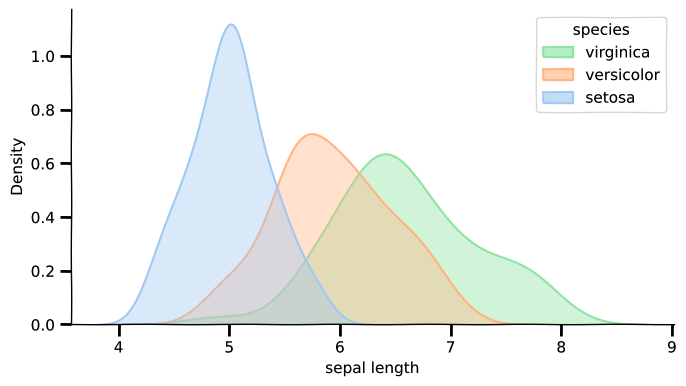

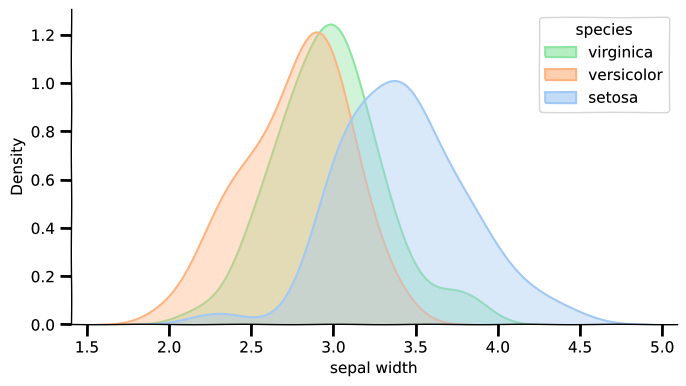

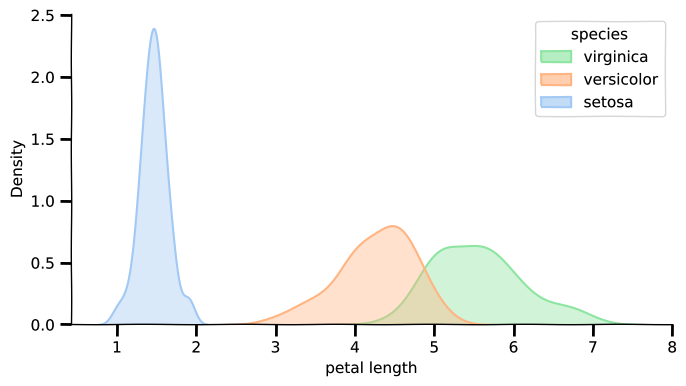

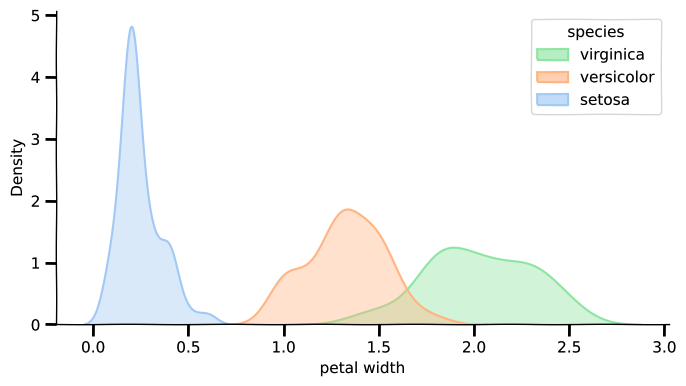

In [8]:
for feature in df.columns[:-1]:
    plt.figure(figsize=(7, 4))
    sns.kdeplot(
        data=df,
        x=feature,
        hue="species",
        fill=True,
        alpha=0.4,
        linewidth=1.5,
        common_norm=False,
        palette="pastel",
        legend=True,
        # hue_order=["Iris-setosa", "Iris-versicolor", "Iris-virginica"],
    )
    plt.xlabel(feature)
    # plt.title(f"{feature} density by type")
    plt.legend(title="species", labels=["virginica", "versicolor", "setosa"])
    sns.despine()
    plt.tight_layout()
    plt.show()

## Histrogram


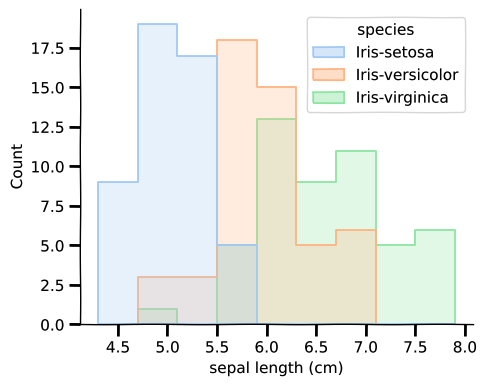

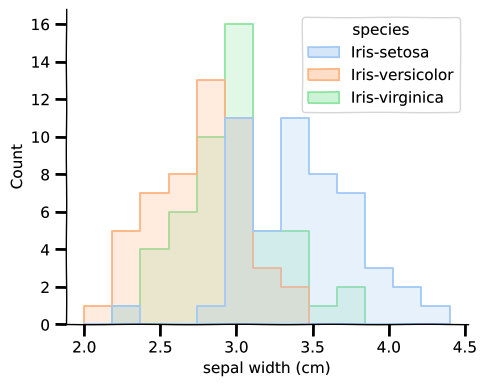

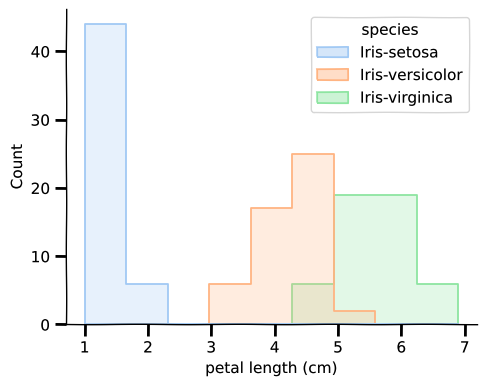

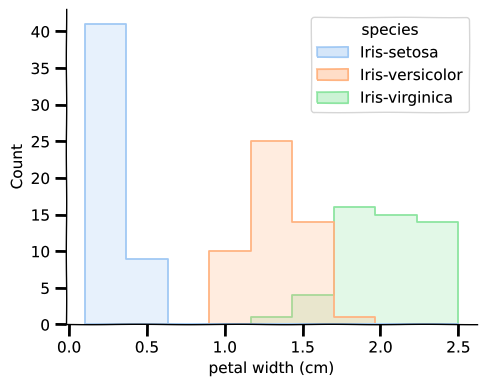

In [9]:
for feature in df.columns[:-1]:
    plt.figure(figsize=(5, 4))
    sns.histplot(
        data=df,
        x=feature,
        hue="species",
        # fill=True,
        # alpha=0.5,
        element="step",
        linewidth=1.3,
        common_norm=False,
        palette="pastel",
        legend=True,
        # kde=True,
        # hue_order=["Iris-setosa", "Iris-versicolor", "Iris-virginica"],
    )
    plt.xlabel(feature + " (cm)")
    # plt.title(f"{feature} density by type")
    # plt.legend(title="species", labels=["virginica", "versicolor", "setosa"])
    sns.despine()
    plt.tight_layout()
    plt.show()

## Pairplot


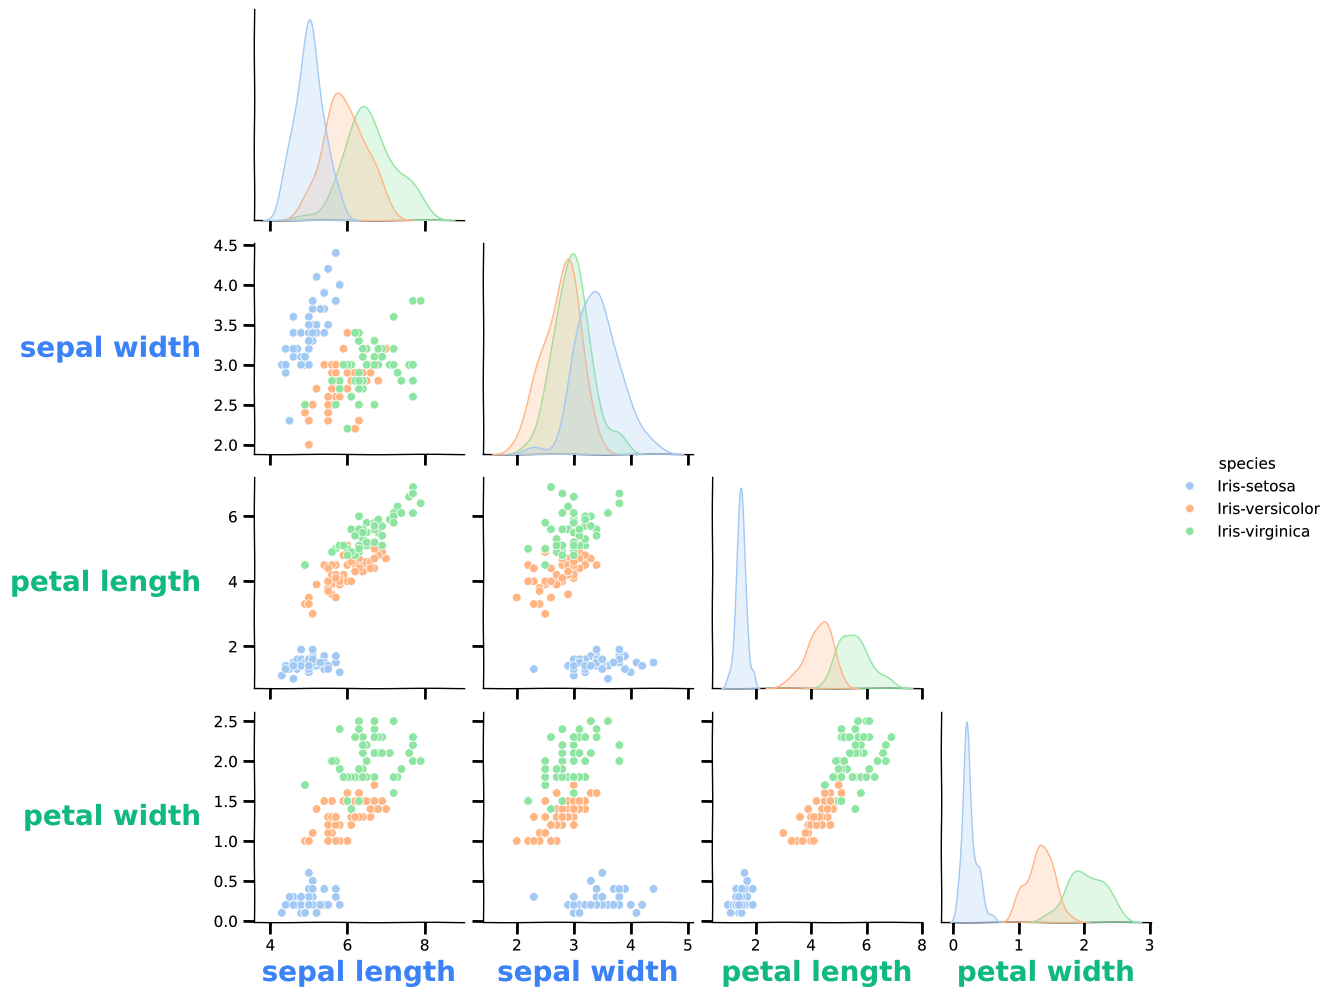

In [10]:
g = sns.pairplot(
    df,
    hue="species",
    palette="pastel",
    diag_kind="kde",
    corner=True,
    # diag_kws=dict(bins=20, alpha=0.6),
    # plot_kws=dict(s=18, alpha=0.55, edgecolor="white", linewidth=0.3),
    # height=2.2,

)

# for ax in g.axes[:, 0]:
#     ax.set_ylabel(ax.get_ylabel(), rotation=0)  # horizontal
#     ax.yaxis.set_label_coords(-0.44, 0.5)       # nudge a bit to the left if needed
#     ax.figure.subplots_adjust(left=0.1)


# ใช้ palette เดียวกับ pairplot ของคุณ
# g.map_offdiag(annotate_corr_by_hue, hue="species", palette=g._legend.get_texts()[0].get_color() if getattr(g, "_legend", None) else None)

# หลังจากสร้าง g = sns.pairplot(...)

SEPAL_COLOR = "#3B82F6"  # ฟ้า
PETAL_COLOR = "#10B981"  # เขียว
LABEL_SIZE_X = 20  # ขนาดฟอนต์แกน X
LABEL_SIZE_Y = 20  # ขนาดฟอนต์แกน Y
LABEL_WEIGHT = "bold"  # หรือ "normal", 300–900 ก็ได้ (ถ้าฟอนต์รองรับ)


def color_for(var: str) -> str:
    v = (var or "").strip().lower()
    if v.startswith("sepal"):
        return SEPAL_COLOR
    if v.startswith("petal"):
        return PETAL_COLOR
    return "black"


n_rows, n_cols = g.axes.shape

x_vars = [g.axes[-1, c].get_xlabel() for c in range(n_cols)]
y_vars = [g.axes[r, 0].get_ylabel() for r in range(n_rows)]

for c, var in enumerate(x_vars):
    ax = g.axes[-1, c]
    ax.set_xlabel(
        var,
        color=color_for(var),
        fontsize=LABEL_SIZE_X,
        fontweight=LABEL_WEIGHT,
    )

for r, var in enumerate(y_vars):
    ax = g.axes[r, 0]
    ax.set_ylabel(
        var,
        rotation=0,
        ha="right",
        va="center",
        color=color_for(var),
        fontsize=LABEL_SIZE_Y,
        fontweight=LABEL_WEIGHT,
    )
    ax.yaxis.set_label_coords(-0.25, 0.5)


sns.despine()
plt.show()

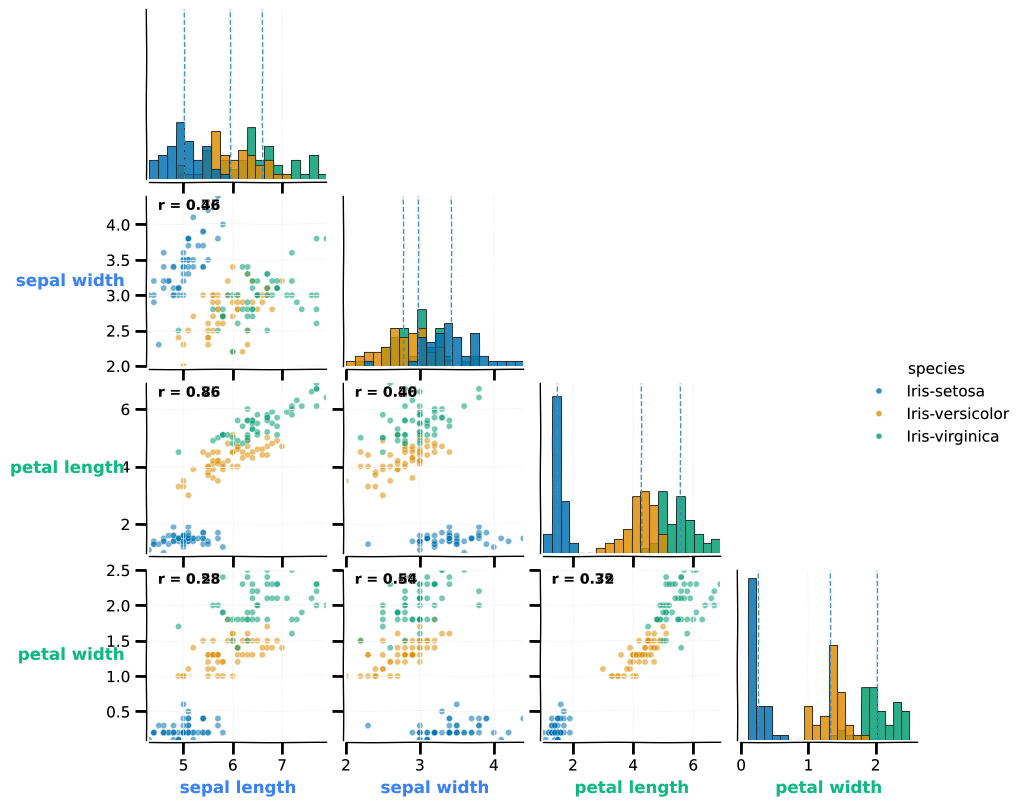

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) สร้าง pairplot: ลดซ้ำซ้อน + จุดอ่านง่าย
g = sns.pairplot(
    df,
    hue="species",
    palette="colorblind",
    corner=True,  # แสดงเฉพาะ lower triangle + diagonal
    diag_kind="hist",
    diag_kws=dict(bins=20, alpha=0.6),
    plot_kws=dict(s=18, alpha=0.55, edgecolor="white", linewidth=0.3),
    height=2.2,
)

# 2) ทำให้แกนทุกช่องใช้ช่วงเดียวกัน (per variable) -> เทียบข้ามกราฟง่าย
#    ดึงช่วงของแต่ละตัวแปรจากคอลัมน์
cols = [g.axes[-1, c].get_xlabel() for c in range(g.axes.shape[1])]
lims = {col: (df[col].min(), df[col].max()) for col in cols}

for r in range(g.axes.shape[0]):
    for c in range(g.axes.shape[1]):
        ax = g.axes[r, c]
        if ax is None:
            continue
        # off-diag เท่านั้น (มีทั้ง x และ y)
        if ax.get_xlabel() and ax.get_ylabel():
            ax.set_xlim(lims[ax.get_xlabel()])
            ax.set_ylim(lims[ax.get_ylabel()])


# 3) ใส่ค่า r บนทุก off-diag
def annotate_corr(x, y, **kws):
    ax = plt.gca()
    if len(x) > 1 and len(y) > 1:
        r = np.corrcoef(x, y)[0, 1]
        ax.text(
            0.05,
            0.92,
            f"r = {r:.2f}",
            transform=ax.transAxes,
            fontsize=10,
            fontweight="bold",
        )


g.map_offdiag(annotate_corr)


# 4) เพิ่มเส้นค่าเฉลี่ยใน diag (ช่วยเล็งศูนย์กลาง)
def diag_mean(x, **kws):
    ax = plt.gca()
    ax.axvline(np.mean(x), ls="--", lw=1, alpha=0.8)


g.map_diag(diag_mean)

# 5) grid จาง ๆ + despine ทุกช่อง
for ax in g.axes.flat:
    if ax is None:
        continue
    ax.grid(True, which="major", linewidth=0.3, alpha=0.25)
    sns.despine(ax=ax, offset=2)

# 6) (ต่อยอดจากที่คุณทำไว้) ย้อมสี/หนา/ขนาด label เฉพาะชื่อแกน (ไม่แตะตัวเลข)
SEPAL_COLOR = "#3B82F6"
PETAL_COLOR = "#10B981"
LABEL_SIZE = 12
LABEL_WEIGHT = "bold"


def color_for(var: str) -> str:
    v = (var or "").strip().lower()
    if v.startswith("sepal"):
        return SEPAL_COLOR
    if v.startswith("petal"):
        return PETAL_COLOR
    return "black"


# X labels (แถวล่างสุด)
for c in range(g.axes.shape[1]):
    ax = g.axes[-1, c]
    lbl = ax.get_xlabel()
    ax.set_xlabel(
        lbl, color=color_for(lbl), fontsize=LABEL_SIZE, fontweight=LABEL_WEIGHT
    )

# Y labels (คอลัมน์ซ้ายสุด) + แนวนอน
for r in range(g.axes.shape[0]):
    ax = g.axes[r, 0]
    lbl = ax.get_ylabel()
    ax.set_ylabel(
        lbl,
        rotation=0,
        ha="right",
        va="center",
        color=color_for(lbl),
        fontsize=LABEL_SIZE,
        fontweight=LABEL_WEIGHT,
    )
    ax.yaxis.set_label_coords(-0.14, 0.5)

# เผื่อขอบไม่ให้ label โดนตัด
g.figure.subplots_adjust(left=0.16, bottom=0.12, right=0.90, top=0.95)

## Scatterplot


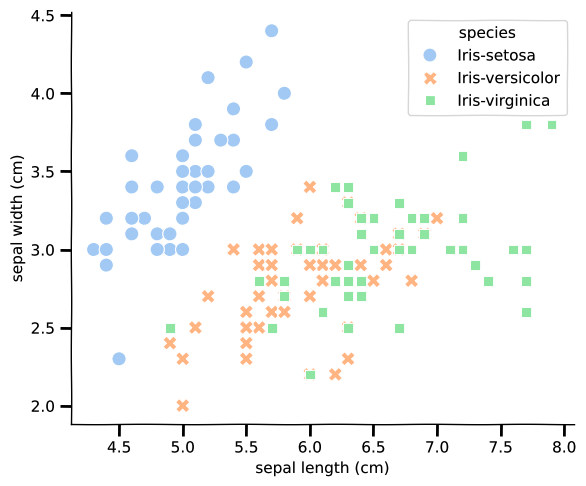

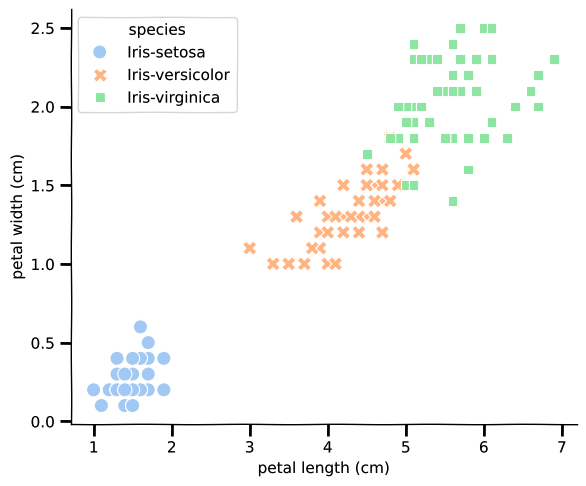

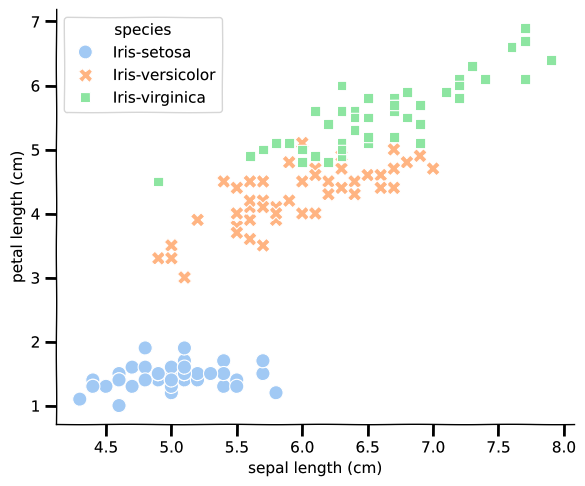

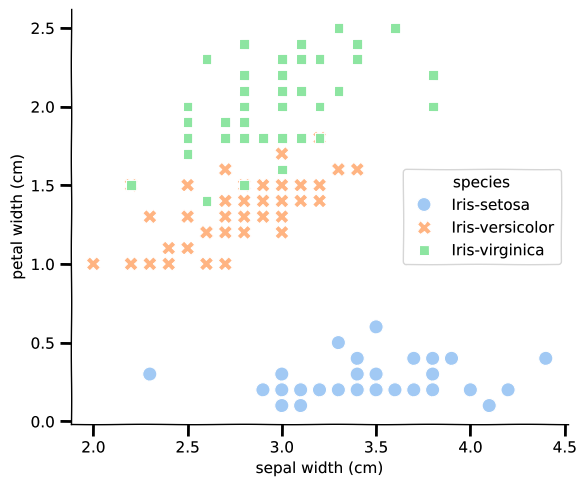

In [12]:
# ## scatterplot

# sns.scatterplot(
#     data=df,
#     x="sepal length",
#     y="sepal width",
#     hue="species",
#     style="species",
#     s=100,
#     palette="pastel",
# )
# plt.xlabel("sepal length (cm)")
# plt.ylabel("sepal width (cm)")
# plt.title("Sepal Length vs Sepal Width")
# # plt.legend(title="species", labels=["virginica", "versicolor", "setosa"])
# sns.despine()
# plt.tight_layout()
# plt.show()


for x_feature, y_feature in [
    ("sepal length", "sepal width"),
    ("petal length", "petal width"),
    ("sepal length", "petal length"),
    ("sepal width", "petal width"),
]:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        data=df,
        x=x_feature,
        y=y_feature,
        hue="species",
        style="species",
        s=100,
        palette="pastel",
    )
    plt.xlabel(x_feature + " (cm)")
    plt.ylabel(y_feature + " (cm)")
    # plt.title(f"{x_feature} vs {y_feature}")
    # plt.legend(title="species", labels=["virginica", "versicolor", "setosa"])
    sns.despine()
    plt.tight_layout()
    plt.show()

## Correlation Matrix


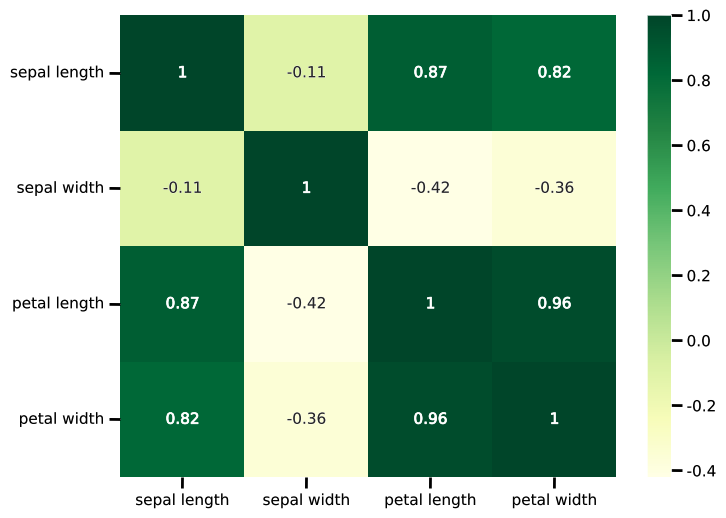

In [13]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
g = sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="YlGn",
    # linewidth = 0.1
)
g.set_yticklabels(g.get_yticklabels(), rotation=0)
# plt.title("Correlation Matrix")
plt.show()

In [14]:
# import numpy as np


# f, ax = plt.subplots(figsize=(11, 9))

# mask = np.triu(np.ones_like(corr, dtype=bool))

# # cmap = sns.diverging_palette(230, 20, as_cmap=True)

# # sns.heatmap(
# #     corr,
# #     mask=mask,
# #     cmap="YlGn",
# #     # vmax=0.3,
# #     # center=0,
# #     square=True,
# #     # linewidths=0.5,
# #     # cbar_kws={"shrink": 0.5},
# # )

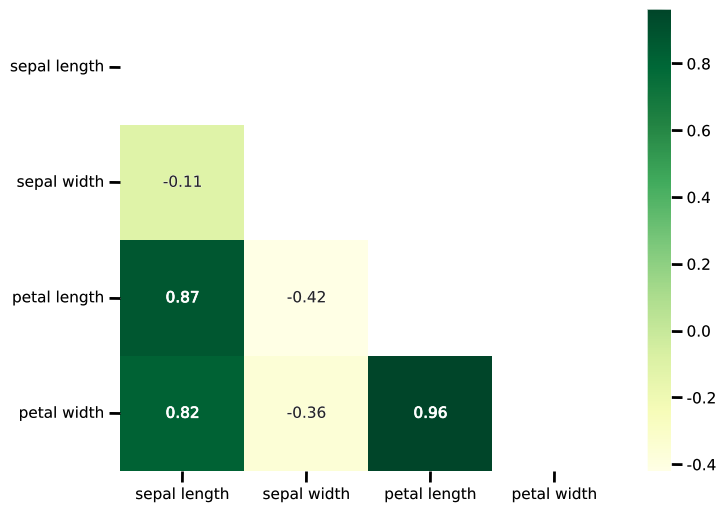

In [15]:
import numpy as np

corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr))
plt.figure(figsize=(8, 6))

# f, ax = plt.subplots(figsize=(16, 12))

dataplot = sns.heatmap(
    corr,
    cmap="YlGn",
    annot=True,
    mask=mask,
)
dataplot.set_yticklabels(dataplot.get_yticklabels(), rotation=0)

plt.show()

## Boxplot


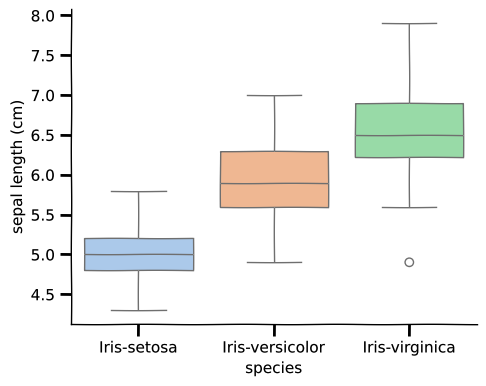

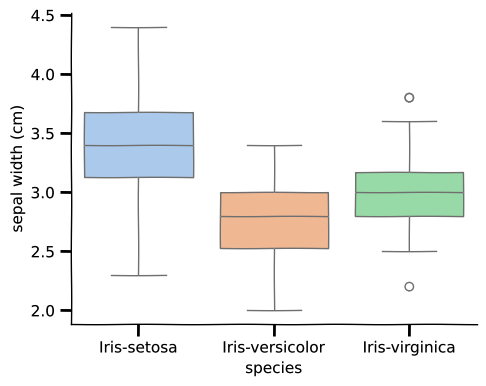

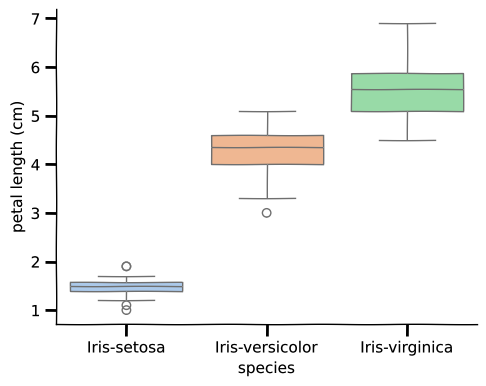

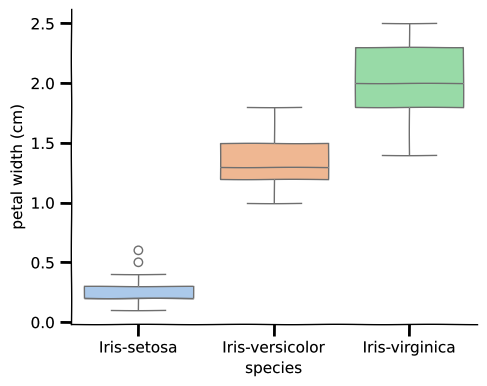

In [16]:
for feature in df.columns[:-1]:
    plt.figure(figsize=(5, 4))
    sns.boxplot(
        data=df,
        x="species",
        y=feature,
        palette="pastel",
        hue="species",
        # whis=[0, 100]
        # legend=True
    )
    # sns.stripplot(data=df, x="species", y=feature, size=4, color=".5")

    plt.xlabel("species")
    plt.ylabel(feature + " (cm)")
    # plt.title(f"{feature} by species")
    sns.despine()
    plt.tight_layout()
    plt.show()

## Crosstab


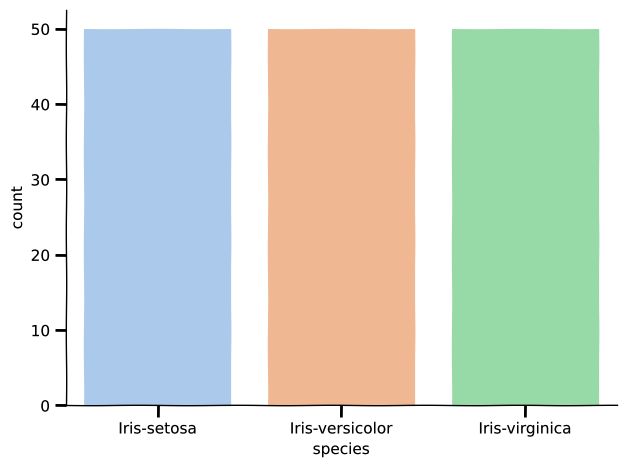

In [17]:
ax = sns.countplot(
    data=df,
    x="species",
    palette="pastel",
    hue="species",
)
plt.xlabel("species")
plt.ylabel("count")
# plt.title("Count of each species")
sns.despine()
plt.tight_layout()
plt.show()

## Handle Outliers


In [18]:
def detection_outlier(dfcolumn: str) -> None:
    # Calculate Q1, Q3 and IQR
    Q1 = dfcolumn.quantile(0.25)
    Q3 = dfcolumn.quantile(0.75)
    IQR = Q3 - Q1  # Interquartile range

    # In general, constant should be 1.
    lower = Q1 - 1 * IQR
    higher = Q3 + 1 * IQR

    # Find number of outliers for specific column
    print("Before data preprocessing:")
    print("Skewness:", dfcolumn.skew())
    print(dfcolumn.describe())

    dfcolumn.loc[(dfcolumn > higher) | (dfcolumn < lower)] = dfcolumn.mean()
    print("After replacing outliers by mean:")
    print("Skewness:", dfcolumn.skew())
    print("Median:", dfcolumn.median())
    print("IQR value:", IQR)
    print("Lower,Higher:", lower, ",", higher)

In [19]:
# grouped = df.groupby('species')
# for name, group in grouped:
#     print(f'\nOutlier detection for {name}:')
#     for column in df.columns[:-1]:
#         print(f'\nFeature: {column}')
#         detection_outlier(group[column])

# detection_outlier(df['petal length'])

In [20]:
def cap_outliers_iqr(series: pd.Series) -> pd.Series:
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return series.clip(lower=lower_bound, upper=upper_bound)


def impute_outliers_iqr_with_inlier_mean(s: pd.Series) -> pd.Series:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)
    inlier_mean = s[~mask].mean()
    return s.where(~mask, inlier_mean)


def impute_outliers_iqr_with_mean(s: pd.Series) -> pd.Series:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)
    return s.where(~mask, s.mean())


group = df.groupby("species")
df["petal length capped"] = group["petal length"].transform(cap_outliers_iqr)
df["petal width capped"] = group["petal width"].transform(cap_outliers_iqr)
df["sepal length capped"] = group["sepal length"].transform(cap_outliers_iqr)
df["sepal width capped"] = group["sepal width"].transform(cap_outliers_iqr)

In [21]:
# for col in df.columns[:-1]:
#     g = df.groupby("species")[col]
#     q1 = g.transform(lambda s: s.quantile(0.25))
#     q3 = g.transform(lambda s: s.quantile(0.75))
#     iqr = q3 - q1
#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr

#     mask = (df[col] < lower) | (df[col] > upper)

#     df.loc[mask, col] = g.transform("mean")

df.head()

,sepal length,sepal width,petal length,petal width,species,petal length capped,petal width capped,sepal length capped,sepal width capped
0,5.1,3.5,1.4,0.2,Iris-setosa,1.4,0.2,5.1,3.5
1,4.9,3.0,1.4,0.2,Iris-setosa,1.4,0.2,4.9,3.0
2,4.7,3.2,1.3,0.2,Iris-setosa,1.3,0.2,4.7,3.2
3,4.6,3.1,1.5,0.2,Iris-setosa,1.5,0.2,4.6,3.1
4,5.0,3.6,1.4,0.2,Iris-setosa,1.4,0.2,5.0,3.6


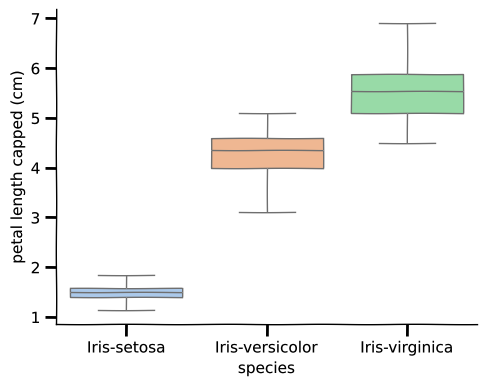

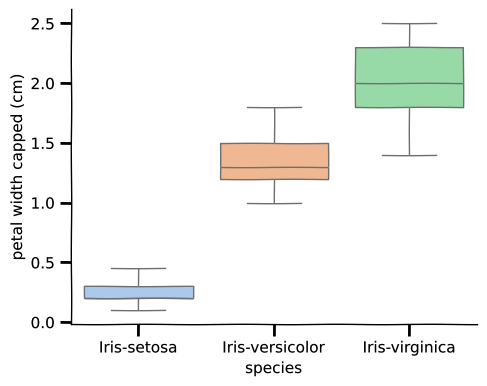

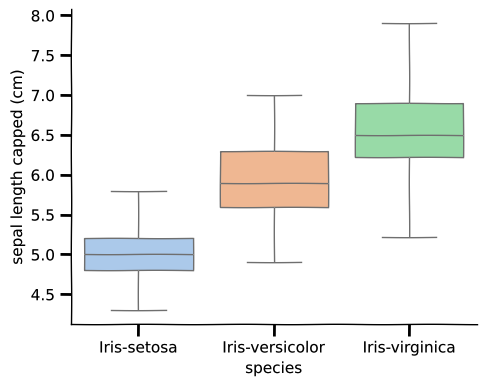

In [22]:
for feature in df.columns[:-1]:
    if not feature.endswith("capped"):
        continue
    plt.figure(figsize=(5, 4))
    sns.boxplot(
        data=df,
        x="species",
        y=feature,
        palette="pastel",
        hue="species",
        # legend=True
    )
    plt.xlabel("species")
    plt.ylabel(feature + " (cm)")
    # plt.title(f"{feature} by species")
    sns.despine()
    plt.tight_layout()
    plt.show()

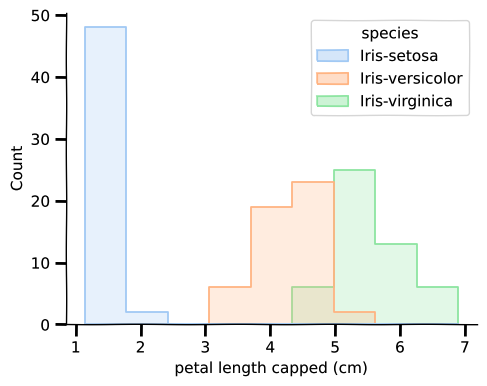

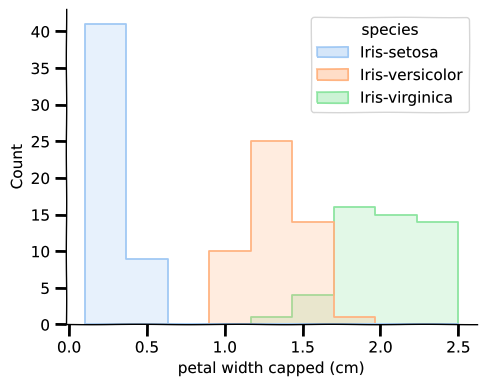

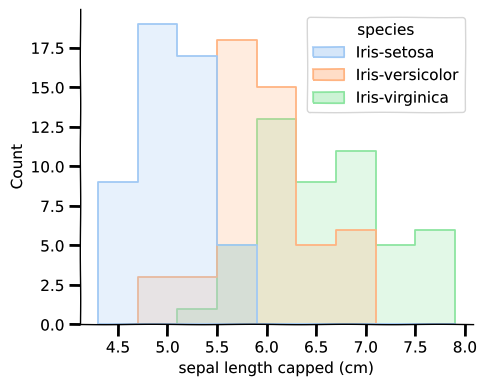

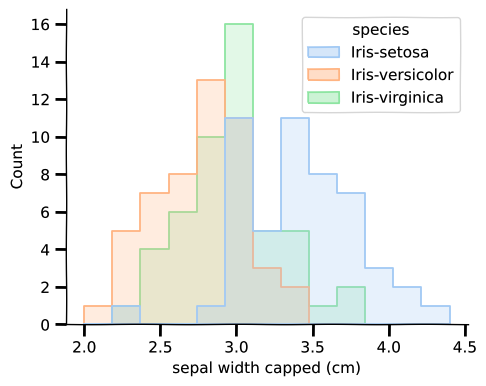

In [23]:
for feature in df.columns:
    if not feature.endswith("capped"):
        continue
    plt.figure(figsize=(5, 4))
    sns.histplot(
        data=df,
        x=feature,
        hue="species",
        # fill=True,
        # alpha=0.5,
        element="step",
        linewidth=1.3,
        common_norm=False,
        palette="pastel",
        legend=True,
        # kde=True,
        # hue_order=["Iris-setosa", "Iris-versicolor", "Iris-virginica"],
    )
    plt.xlabel(feature + " (cm)")
    # plt.title(f"{feature} density by type")
    # plt.legend(title="species", labels=["virginica", "versicolor", "setosa"])
    sns.despine()
    plt.tight_layout()
    plt.show()

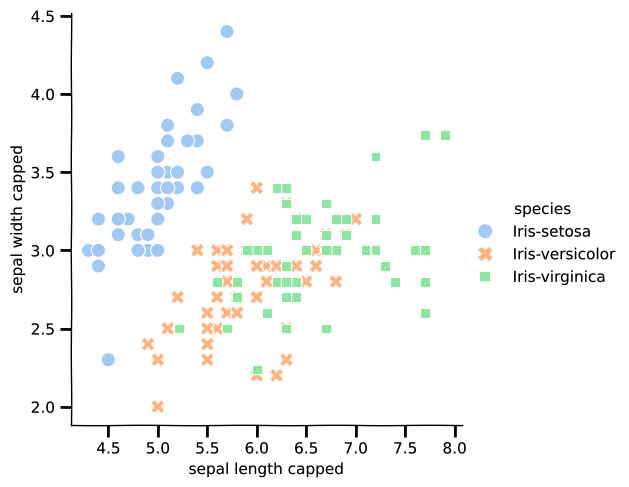

In [24]:
sns.relplot(
    data=df,
    x="sepal length capped",
    y="sepal width capped",
    hue="species",
    style="species",
    s=100,
    palette="pastel",
)